![PNS](http://caillau.perso.math.cnrs.fr/logo-pns.png)
## MAM5-INUM - Commande optimale
# TP 3 - Navigation problem (a.k.a. Zermelo-Markov-Dubins), MPC approach

One considers a ship in a constant current $w=(w_x,w_y)$, $|w| \lt 1$. The angle of the velocity (*wrt.* to the water) is controlled, leading to the following dynamics:

$$ \begin{array}{rcl}
     \dot{x}(t) &=& w_x+\cos\theta(t),\quad t \in [0,t_f]\\
     \dot{y}(t) &=& w_y+\sin\theta(t),\\
     \dot{\theta}(t) &=& u(t). 
   \end{array} $$

The turning rate (= curvature of turns) is limited, so $|u(t)| \leq 1$. There boundary conditions at $t=0$ and $t=t_f$ on the position $(x,y)$ and on the angle $\theta$ of the velocity in the water referential. The final time is to be minimised. The problem originates from a collaboration with the French company [CGG](https://www.cgg.com) that is interested in optimal maneuvers for very large ships doing marine prospection.

![ship](ship.png)

In [1]:
using JuMP, Ipopt, Plots, OrdinaryDiffEq, LinearAlgebra

# Problem definition
t0 = 0.
x0 = 0. 
y0 = 0.
θ0 = π/7
xf = 4.
yf = 7.
θf =-π/2

function drift(x, y) # current as a function of position
    ε = 1e-2
    w = [ 0.6, 0.4 ]
    δw = ε * [ y, -x ] / sqrt(1+x^2+y^2)
    w = w + δw
    if (w[1]^2 + w[2]^2 >= 1)
        error("|w| >= 1")
    end
    return w
end

drift (generic function with 1 method)

In [2]:
# Solver (JuMP)
function solve(x0, y0, θ0, xf, yf, θf, w, P=50; tol=1e-8, max_iter=500, print_level=5)
    
    sys = Model(optimizer_with_attributes(Ipopt.Optimizer,"print_level"=>print_level))
    set_optimizer_attribute(sys, "tol", tol)
    set_optimizer_attribute(sys, "max_iter", max_iter)
    
    # TO BE UPDATED
    us = zeros(3)
    τs = ones(3)
    
    return us, τs
    
end

solve (generic function with 2 methods)

In [3]:
# Simulation of the real system
function trajectory(tspan, x0, y0, θ0, us, ts, drift; abstol=1e-12, reltol=1e-12, saveat=[])
    
    function rhs!(dX, X, dummy, t)
        w = drift(X[1], X[2])
        if t < ts[1]
            u = us[1]
        elseif t < ts[2]
            u = us[2]
        else
            u = us[3]
        end
        dX[1] = w[1]+cos(X[3])
        dX[2] = w[2]+sin(X[3])
        dX[3] = u
    end
    
    X0 = [ x0, y0, θ0 ]
    ode = ODEProblem(rhs!, X0, tspan)
    sol = OrdinaryDiffEq.solve(ode, Tsit5(), abstol=abstol, reltol=reltol, saveat=saveat)
    return sol
    
end

trajectory (generic function with 1 method)

In [4]:
# Main loop
Nmax = 20      # max number iterations
ε = 1e-1       # final condition threshold
Δt = 1.0       # fixed time step for MPC
P = 20         # number of points for direct solve

t1 = t0
x1 = x0
y1 = y0
θ1 = θ0

t = [ ]
x = [ ]
y = [ ]
θ = [ ]
u = [ ]

N = 1

while true
    
    w = drift(x1, y1) # current sampled at (x1,y1)
    us, τs = solve(x1, y1, θ1, xf, yf, θf, w, P, print_level=0)
    ts = [ t1+τs[1], t1+τs[1]+τs[2] ]
    tf = t1+τs[1]+τs[2]+τs[3]
    if (t1+Δt < tf)
        t2 = t1+Δt
    else
        t2 = tf
        println("t2=tf: ", t2)
    end
    sol = trajectory((t1, t2), x1, y1, θ1, us, ts, drift)
    t = [ t ; sol.t ]
    x = [ x ; sol[1, :] ]
    y = [ y ; sol[2, :] ]
    θ = [ θ ; sol[3, :] ]
    uu = zeros(length(sol.t))
    uu[ findall(sol.t .< ts[1]) ] .= us[1]
    uu[ findall(ts[1] .<= sol.t .< ts[2]) ] .= us[2]
    uu[ findall(sol.t .>= ts[2]) ] .= us[3]
    u = [ u ; uu ]
    
    t1 = t2
    x1 = x[end]
    y1 = y[end]
    θ1 = θ[end]
    err = norm([ x1, y1, θ1 ] - [ xf, yf, θf ])
    println("N: ", N, "\t err: ", err)
    ((err > ε) && (N <= Nmax)) || break
    N = N+1
    
end

N: 1	 err: 6.956515182194702
N: 2	 err: 5.799441499075159
N: 3	 err: 4.977387363663957
N: 4	 err: 4.670415723350004
N: 5	 err: 4.974739661294012
N: 6	 err: 5.794816532713548
N: 7	 err: 6.950414892201333
N: 8	 err: 8.302595048868481
N: 9	 err: 9.770072609107396
N: 10	 err: 11.308048023077289
N: 11	 err: 12.891313565505259
N: 12	 err: 14.505045876405443
N: 13	 err: 16.140108889683283
N: 14	 err: 17.790622192117745
N: 15	 err: 19.452653323128022
N: 16	 err: 21.123483665177112
N: 17	 err: 22.8011788794632
N: 18	 err: 24.484327802508766
N: 19	 err: 26.171878221273936
N: 20	 err: 27.86303038331493
N: 21	 err: 29.55716604234688


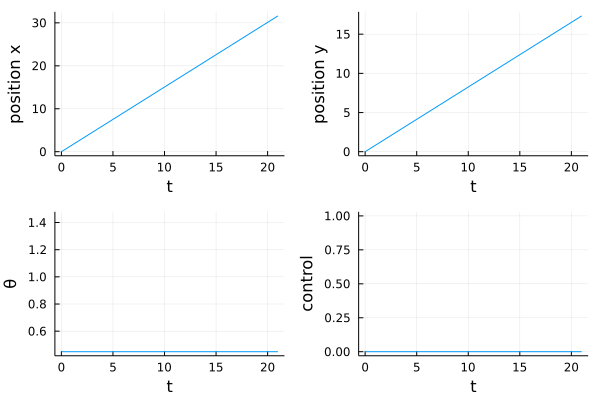

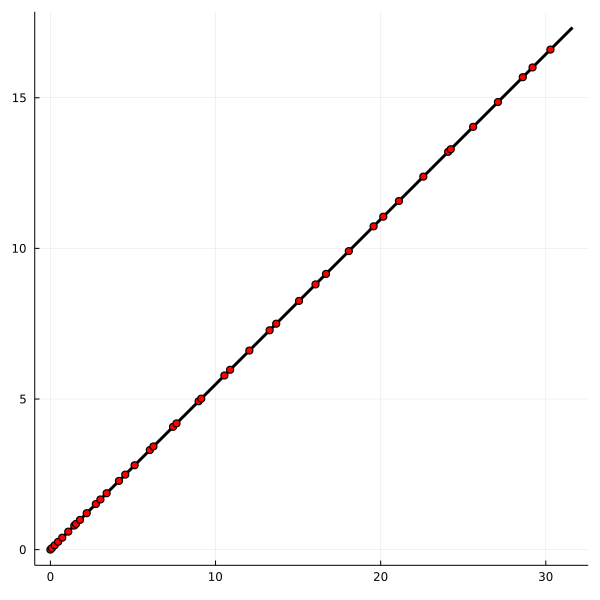

In [5]:
# Plots: states and control
x_plot = plot(t, x, xlabel="t", ylabel="position x", legend=false, fmt=:png)
y_plot = plot(t, y, xlabel="t", ylabel="position y", legend= false, fmt=:png)
θ_plot = plot(t, θ, xlabel="t", ylabel="θ", legend=false, fmt=:png)
u_plot = plot(t, u, xlabel="t", ylabel="control", legend=false, fmt=:png)
display(plot(x_plot, y_plot, θ_plot, u_plot, layout = (2,2)))

# Plots: trajectory 
traj_plot = plot(x, y, color=:black, lw=3)
plot!(size=(600,600))

step = 5
for i = 1:step:length(t)
    plot!([ x[i] ], [ y[i] ], seriestype = :scatter, color =:red, legend = false) 
end
display(traj_plot)